## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import pickle

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Step 2: Load IMDb Dataset

In [2]:
num_words = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

print("Training Samples:", len(x_train))
print("Testing Samples :", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Samples: 25000
Testing Samples : 25000


## Step 3: Decode Reviews into Text

In [3]:
word_index = imdb.get_word_index()

reverse_word_index = {
    value: key for key, value in word_index.items()
}

def decode_review(review):
    return " ".join(
        reverse_word_index.get(i - 3, "?")
        for i in review
    )

train_reviews = [decode_review(r) for r in x_train]
test_reviews = [decode_review(r) for r in x_test]

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Step 4: Display a Sample Review

0 = Negative

1 = Positive

In [4]:
print(train_reviews[0])
print("\nSentiment:", y_train[0])

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

## Step 5: Convert Text to TF-IDF Features

In [5]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train = vectorizer.fit_transform(train_reviews)
X_test = vectorizer.transform(test_reviews)

## Step 6: Train Logistic Regression

In [6]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Step 7: Predict

In [7]:
lr_pred = lr_model.predict(X_test)

## Step 8: Evaluate Logistic Regression

In [8]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print(classification_report(
    y_test,
    lr_pred
))

Accuracy: 0.87824
              precision    recall  f1-score   support

           0       0.88      0.87      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



## Step 9: Confusion Matrix

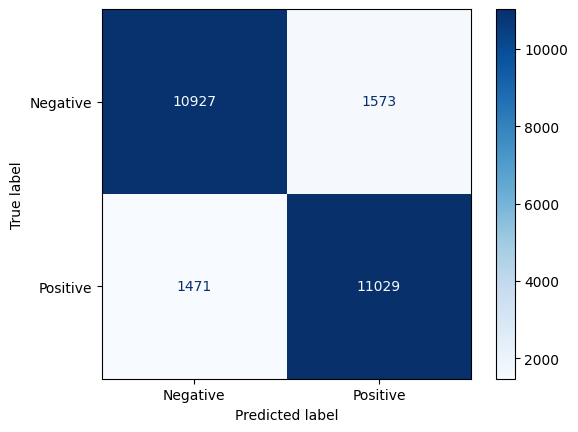

In [9]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap="Blues")
plt.show()

## Step 10: Save Logistic Regression Model

In [10]:
pickle.dump(
    lr_model,
    open("logistic_model.pkl","wb")
)

## Step 11: Train Support Vector Machine (SVM)

In [11]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

LinearSVC()

## Step 12: Predict Using SVM

In [12]:
svm_pred = svm_model.predict(X_test)

## Step 13: Evaluate SVM

In [13]:
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(
    y_test,
    svm_pred
))

SVM Accuracy: 0.86124
              precision    recall  f1-score   support

           0       0.86      0.87      0.86     12500
           1       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



## Step 14: SVM Confusion Matrix

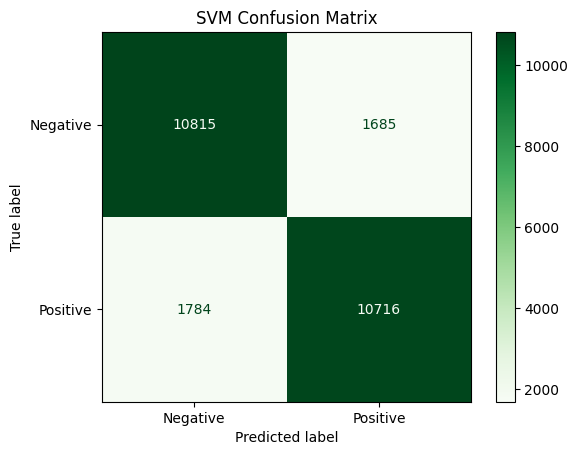

In [14]:
cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.show()

## Step 15: Save SVM Model

In [15]:
pickle.dump(
    svm_model,
    open("svm_model.pkl","wb")
)

## Step 16: Prepare Data for LSTM

In [16]:
maxlen = 200

x_train_pad = pad_sequences(
    x_train,
    maxlen=maxlen
)

x_test_pad = pad_sequences(
    x_test,
    maxlen=maxlen
)

print(x_train_pad.shape)
print(x_test_pad.shape)

(25000, 200)
(25000, 200)


## Step 17: Build the LSTM Model

In [17]:
lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=maxlen),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 18: Train the LSTM Model

In [18]:
history = lstm_model.fit(
    x_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 124s 380ms/step - accuracy: 0.7958 - loss: 0.4268 - val_accuracy: 0.8606 - val_loss: 0.3228
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 378ms/step - accuracy: 0.9036 - loss: 0.2427 - val_accuracy: 0.8406 - val_loss: 0.3592
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 254ms/step - accuracy: 0.9147 - loss: 0.2199 - val_accuracy: 0.8700 - val_loss: 0.3285
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 254ms/step - accuracy: 0.9553 - loss: 0.1253 - val_accuracy: 0.8564 - val_loss: 0.3604
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.9624 - loss: 0.1055 - val_accuracy: 0.8604 - val_loss: 0.4508


## Step 19: Plot Accuracy

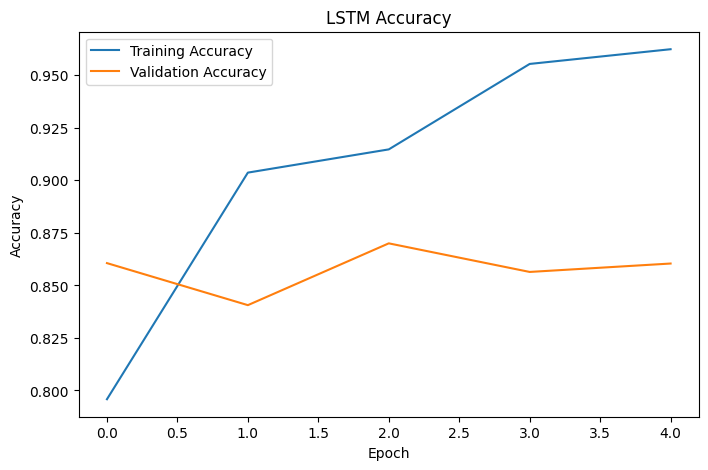

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Step 20: Plot Loss

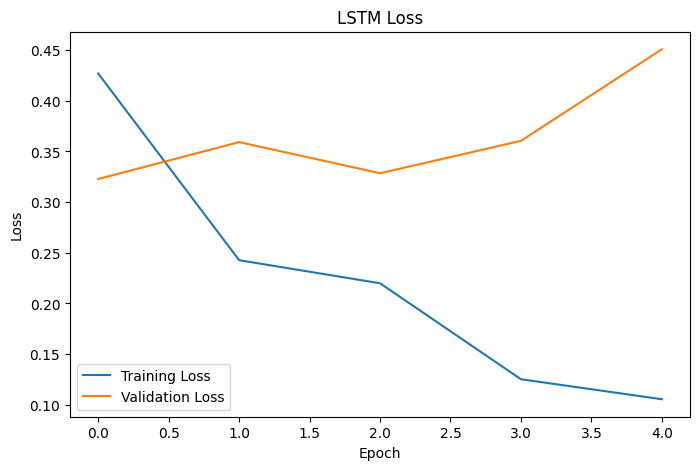

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Step 21: Evaluate the LSTM Model

In [22]:
loss, accuracy = lstm_model.evaluate(
    x_test_pad,
    y_test
)

print("LSTM Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.8569 - loss: 0.4536
LSTM Accuracy: 0.8569200038909912


## Step 22: Make Predictions

In [23]:
pred = lstm_model.predict(x_test_pad)

pred_classes = (pred > 0.5).astype(int).flatten()

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step


## Step 23: Classification Report

In [24]:
print(classification_report(
    y_test,
    pred_classes
))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85     12500
           1       0.84      0.89      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



## Step 24: Confusion Matrix

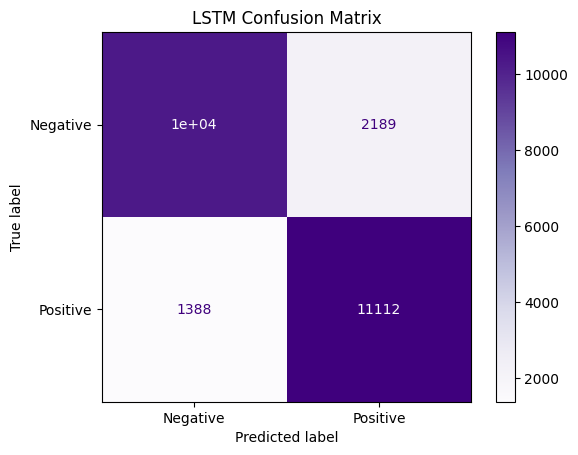

In [25]:
cm = confusion_matrix(
    y_test,
    pred_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap="Purples")

plt.title("LSTM Confusion Matrix")

plt.show()

## Step 25: Save the LSTM Model

In [32]:
from google.colab import files

files.download("lstm_sentiment_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 26: Compare All Models

In [27]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "LSTM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy
    ]
})

print(results)

                    Model  Accuracy
0     Logistic Regression   0.87824
1  Support Vector Machine   0.86124
2                    LSTM   0.85692


## Step 27: Plot Model Comparison

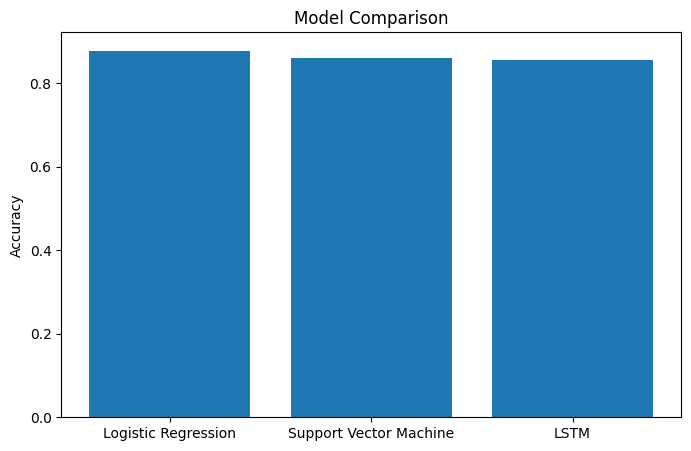

In [28]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

## Step 28: Test with Your Own Review

In [29]:
review = "This movie was fantastic. I really enjoyed it."

review_vector = vectorizer.transform([review])

prediction = lr_model.predict(review_vector)

if prediction[0] == 1:
    print("😊 Positive Review")
else:
    print("😞 Negative Review")

😊 Positive Review


In [30]:
review = "Worst movie ever. Waste of time."

review_vector = vectorizer.transform([review])

prediction = lr_model.predict(review_vector)

if prediction[0] == 1:
    print("😊 Positive Review")
else:
    print("😞 Negative Review")

😞 Negative Review
